In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np

In [18]:
def read_loss_files(file_train, file_valid):
    # Read training and validation loss files from all csv-files in file_train and file_valid, combine into single dataframe along 'time' column
    df_train_list = [pd.read_csv(f, names=['time', 'train_mse_loss', 'step'], index_col=False, sep=' ') for f in file_train]
    df_valid_list = [pd.read_csv(f, names=['time', 'val_mse_loss', 'step'], index_col=False, sep=' ') for f in file_valid]
    # Concat if more than one file
    if len(df_train_list) > 1:
        df_train = pd.concat(df_train_list, ignore_index=True)
        df_valid = pd.concat(df_valid_list, ignore_index=True)
    else:
        df_train = df_train_list[0]
    # Sort dataframes by 'time' column
    df_train = df_train.sort_values(by='time')
    # Reset index
    df_train = df_train.reset_index(drop=True)
    if len(df_valid_list) > 0:
        df_valid = df_valid_list[0]
        df_valid = df_valid.sort_values(by='time')
        df_valid = df_valid.reset_index(drop=True)
    else:
        df_valid = None
    # Fix steps to be increasing, since we have put together multiple csv-files
    idxs = np.where(df_train.step == df_train.step.min())[0]
    print(idxs)
    for i in range(1, len(idxs)):
        idx0 = idxs[i]
        idx1 = idxs[i+1]-1 if i+1 < len(idxs) else len(df_train)
        # Get the last value from the previous segment
        lastval = df_train.loc[idx0-1, 'step']
        df_train.loc[idx0:idx1, 'step'] += lastval
        print(f"Fixed steps from {idx0} to {idx1}, added {lastval}")
    return df_train, df_valid

In [19]:
# commondir1   = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/logs/mlflow/698849147428657484'
commondir1   = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/logs/mlflow/368434394705793063'
file_train1 = glob.glob(os.path.join(commondir1, '*/metrics/train_mse_loss_step'))
file_valid1 = glob.glob(os.path.join(commondir1, '*/metrics/val_mse_loss_step'))
df_train_e1, df_valid_e1 = read_loss_files(file_train1, file_valid1)


[0]


In [20]:
# commondir2   = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph/logs/mlflow/265326910159272697'
commondir2   = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/logs/mlflow/722516445184881513'
file_train2 = glob.glob(os.path.join(commondir2, '*/metrics/train_mse_loss_step'))
file_valid2 = glob.glob(os.path.join(commondir2, '*/metrics/val_mse_loss_step'))
df_train_e2, df_valid_e2 = read_loss_files(file_train2, file_valid2)

[0]


In [21]:
# plot_this = [(df_train_e3, 'Run e-3'), (df_train_e4, 'Run e-4'), (df_train, 'Run e-4')]
# plot_this = [(df_train_e1, '90s_uncorr'), (df_train_e2, '90s_corrected')]
plot_this = [(df_train_e1, '90s_uncorr')]
# plot_this = [(df_train, 'Run 10 years e-4'), (df_valid, 'Validation 10 years e-4')]

In [22]:
# # Fix steps to be increasing, since we have put together multiple csv-files
# idxs = np.where(df_train.step == df_train.step.min())[0]
# print(idxs)
# for i in range(1, len(idxs)):
#     idx0 = idxs[i]
#     idx1 = idxs[i+1]-1 if i+1 < len(idxs) else len(df_train)
#     # Get the last value from the previous segment
#     lastval = df_train.loc[idx0-1, 'step']
#     df_train.loc[idx0:idx1, 'step'] += lastval
#     print(f"Fixed steps from {idx0} to {idx1}, added {lastval}")

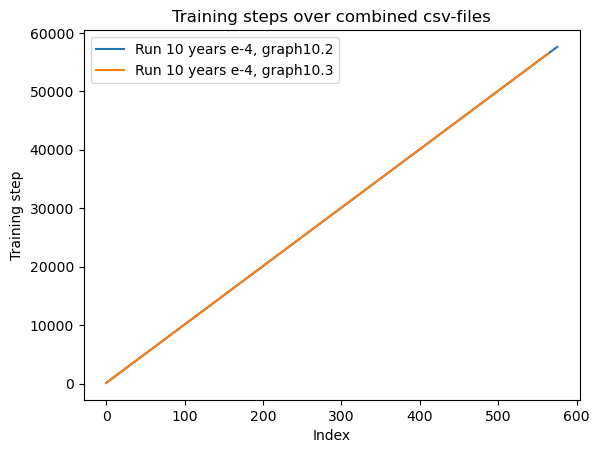

In [23]:
plt.plot(df_train_e1.index, df_train_e1.step)
plt.plot(df_train_e2.index, df_train_e2.step)
plt.xlabel('Index')
plt.ylabel('Training step')
plt.title('Training steps over combined csv-files')
plt.legend(['Run 10 years e-4, graph10.2', 'Run 10 years e-4, graph10.3'])
plt.show()

In [24]:
# df_train = pd.read_csv(file_train, names=['time', 'train_mse_loss', 'step'], index_col=False, sep=' ')
# df_valid = pd.read_csv(file_valid, names=['time', 'val_mse_loss', 'step'], index_col=False, sep=' ')

In [25]:
# commondir   = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun3/logs/mlflow/694110302176869916'
# file_train = os.path.join(commondir, 'ada01cf711a3442dbe86f083e8156ab2/metrics/train_mse_loss_step')
# file_valid = os.path.join(commondir, 'ada01cf711a3442dbe86f083e8156ab2/metrics/val_mse_loss_step')
# df_train = pd.read_csv(file_train, names=['time', 'train_mse_loss', 'step'], index_col=False, sep=' ')

In [26]:
# # Using rate: 6.25e-3
# commondir   = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun3/logs/mlflow/694110302176869916'
# file_train_e3 = os.path.join(commondir, 'cb1e8e488f954bf8b6e8840f0ee8cb7e/metrics/train_mse_loss_step')
# file_valid_e3 = os.path.join(commondir, 'cb1e8e488f954bf8b6e8840f0ee8cb7e/metrics/val_mse_loss_step')
# df_train_e3 = pd.read_csv(file_train_e3, names=['time', 'train_mse_loss', 'step'], index_col=False, sep=' ')


In [27]:
# # Using rate: 6.25e-4
# commondir   = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun3/logs/mlflow/694110302176869916'
# file_train_e4 = os.path.join(commondir, '3365c0c0a61340b6892dd7b51034c90d/metrics/train_mse_loss_step')
# file_valid_e4 = os.path.join(commondir, '3365c0c0a61340b6892dd7b51034c90d/metrics/val_mse_loss_step')
# df_train_e4 = pd.read_csv(file_train_e4, names=['time', 'train_mse_loss', 'step'], index_col=False, sep=' ')

In [28]:
# # Read the training files into pandas dataframes
# if False: # If reading two files:
#     # Read the two files into pandas dataframes
#     df1_train = pd.read_csv(file1_train, names=['time', 'train_mse_loss', 'step'], index_col=False, sep=' ')
#     df2_train = pd.read_csv(file2_train, names=['time', 'train_mse_loss', 'step'], index_col=False, sep=' ')
#     # if two dataframes, df1_train and df2_train, combine the two into one dataframe df_train:
#     df_train = pd.concat([df1_train, df2_train], ignore_index=True)
#     df_train = df_train.sort_values(by='step').reset_index(drop=True)
# else:
#     df_train = pd.read_csv(file_train, names=['time', 'train_mse_loss', 'step'], index_col=False, sep=' ')
# # Read the validation file into a pandas dataframe
# try:
#     df_valid = pd.read_csv(file_valid, names=['time', 'val_mse_loss', 'step'], index_col=False, sep=' ')
# except Exception as e:
#     print(f"Error reading validation file: {e}")

In [29]:
def plot_stuff(df, label, deg=3):
    import numpy as np
    try:
        plt.plot(df['step'], df['train_mse_loss'], label=label)
        # Do regression using polyfit on df1['train_mse_loss'] vs df1['step']
        z = np.polyfit(df['step'], df['train_mse_loss'], deg)
    except:
        plt.plot(df['step'], df['val_mse_loss'], label=label)
        # Do regression using polyfit on df1['val_mse_loss'] vs df1['step']
        z = np.polyfit(df['step'], df['val_mse_loss'], deg)
    p = np.poly1d(z)
    plt.plot(df['step'], p(df['step']), "--", label=f'{label} Trendline')


In [30]:
print(f"Training data from {df_train_e1['step'].min()} to {df_train_e1['step'].max()}, {len(df_train_e1)} points")
print(f"Training data from {df_train_e2['step'].min()} to {df_train_e2['step'].max()}, {len(df_train_e2)} points")

Training data from 99 to 57599, 576 points
Training data from 99 to 56499, 565 points


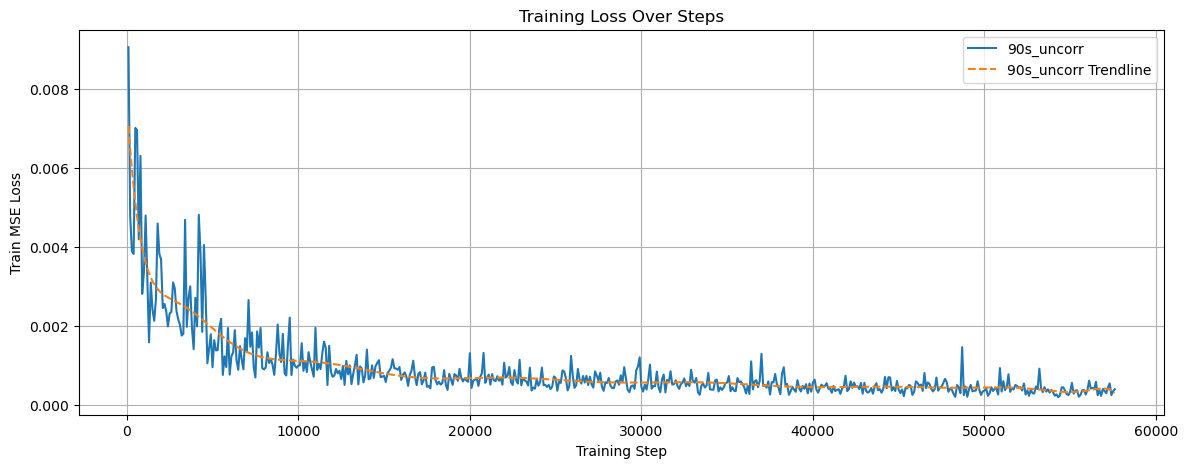

In [37]:
import numpy as np
deg = 15
# Specfi bigger figure for better visibility
plt.figure(figsize=(14, 5))
for df_extra, label in plot_this:
    plot_stuff(df_extra, label, deg)
    # plt.plot(df_extra['step'], df_extra['train_mse_loss'], label=label)
    # # Do regression using polyfit on df1['train_mse_loss'] vs df1['step']
    # z = np.polyfit(df_extra['step'], df_extra['train_mse_loss'], deg)
    # p = np.poly1d(z)
    # plt.plot(df_extra['step'], p(df_extra['step']), "--", label=f'{label} Trendline')
#
# plt.yscale('log')
plt.xlabel('Training Step')
plt.ylabel('Train MSE Loss')
plt.title('Training Loss Over Steps')
# plt.ylim(0, 0.035)
plt.legend()
plt.grid(True)
# # Insert vertical lines at idxs
# for idx in idxs[1:]:
#     plt.axvline(x=df_train.loc[idx, 'step'], color='red', linestyle='--', alpha=0.5)
plt.show()

In [32]:
# import numpy as np
# deg = 2
# # Specfi bigger figure for better visibility
# plt.figure(figsize=(14, 5))
# plt.plot(df_valid['step'], df_valid['val_mse_loss'], label='Run 1')
# # Do regression using polyfit on df1['train_mse_loss'] vs df1['step']
# z = np.polyfit(df_valid['step'], df_valid['val_mse_loss'], deg)
# p = np.poly1d(z)
# plt.plot(df_valid['step'], p(df_valid['step']), "r--", label='Run 1 Trendline')
# # Calculate and plot a running average for smoothing the combined data
# df_valid['val_mse_loss_smooth'] = df_valid['val_mse_loss'].rolling(window=30).mean()
# plt.plot(df_valid['step'], df_valid['val_mse_loss_smooth'], "m-", label='Run 1 Smoothed (window=30)')
# #
# # plt.yscale('log')
# plt.xlabel('Training Step')
# plt.ylabel('Val MSE Loss')
# plt.title('Validation Loss Over Steps')
# plt.ylim(0, 0.035)
# plt.legend()
# plt.grid(True)
# plt.show()